In [1]:
%pip install pandas plotly matplotlib seaborn scikit-learn nbformat joblib

  Using cached pandas-3.0.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached plotly-7.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached numpy-2.5.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached contourpy-1.4.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (130 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-

In [2]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# El Wine Quality dataset está en el repositorio de UCI Machine Learning
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# OJO: Los datos vienen separados por punto y coma (;)
df = pd.read_csv(url, sep=';')
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/wine_original.csv", index=False)

In [5]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
df = df.dropna()
print(df.shape)

(1599, 12)


In [7]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

240
(1359, 12)


In [8]:
df[["alcohol", "pH", "volatile acidity", "residual sugar"]].describe()

,alcohol,pH,volatile acidity,residual sugar
count,1359.000000,1359.000000,1359.000000,1359.000000
mean,10.432315,3.309787,0.529478,2.523400
std,1.082065,0.155036,0.183031,1.352314
min,8.400000,2.740000,0.120000,0.900000
25%,9.500000,3.210000,0.390000,1.900000
50%,10.200000,3.310000,0.520000,2.200000
75%,11.100000,3.400000,0.640000,2.600000
max,14.900000,4.010000,1.580000,15.500000


In [9]:
df["quality"].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [10]:
# Convertimos 'quality' a texto para que Plotly lo trate como categorías (grupos)
df["quality"] = df["quality"].astype(str)

In [11]:
df.to_csv("data/vinos_limpios.csv", index=False)

In [12]:
colores = {
    "3": "#4CC9F0",
    "4": "#F2C14E",
    "5": "#F25C54",
    "6": "#B388EB",
    "7": "#1ED760",
    "8": "#FF8C00"
}

# ¿Cómo se relaciona el alcohol con la calidad?
fig = px.box(df, x="quality", y="alcohol", color="quality", color_discrete_map=colores, category_orders={"quality": ["3", "4", "5", "6", "7", "8"]})
fig.show()

In [13]:
# ¿Cómo se relaciona la acidez volátil con el alcohol?
fig = px.scatter(df, x="alcohol", y="volatile acidity", color="quality",
                 color_discrete_map=colores, opacity=0.6, category_orders={"quality": ["3", "4", "5", "6", "7", "8"]})
fig.show()

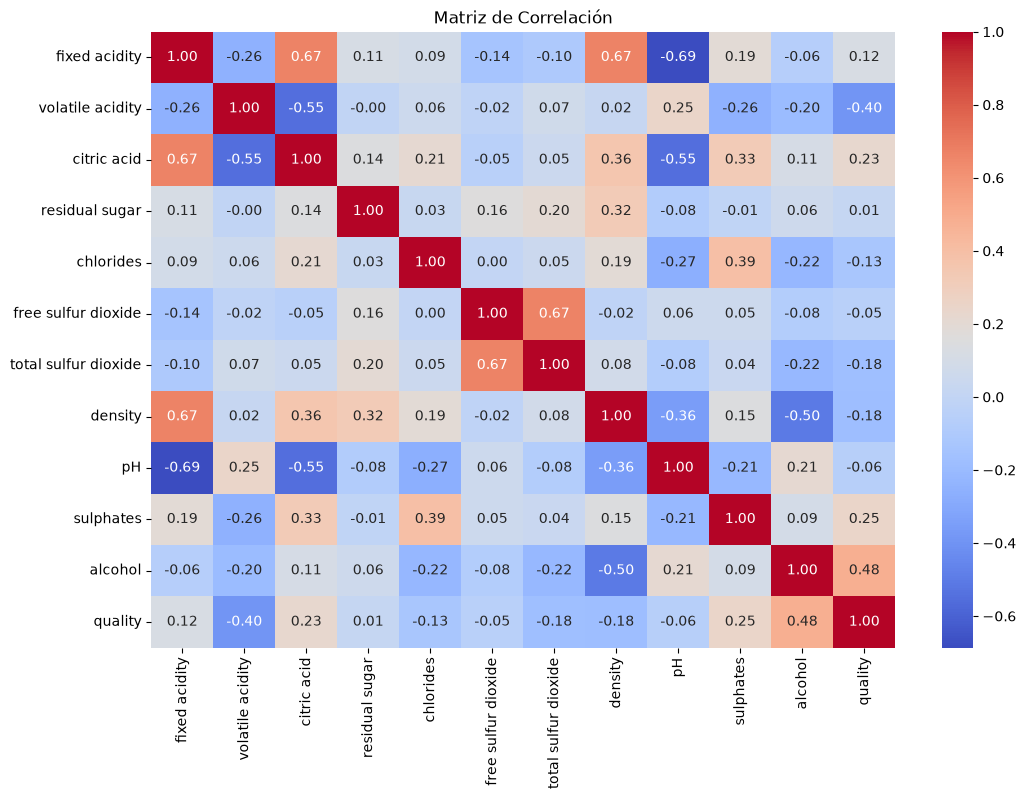

In [14]:
plt.figure(figsize=(12, 8))
# Volvemos a hacer numérico 'quality' solo para esta matriz
df_num = df.copy()
df_num["quality"] = df_num["quality"].astype(int)
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [15]:
# Definimos las variables predictoras (X) y la variable a predecir (y)
X = df.drop("quality", axis=1)
y = df["quality"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1087, 11) (272, 11)


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, pred_knn)
print(f"Accuracy of KNN: ", acc_knn)

Accuracy of KNN:  0.4963235294117647


In [17]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
escalador.fit(X_train)

X_train_esc = pd.DataFrame(escalador.transform(X_train), columns=X.columns)
X_test_esc = pd.DataFrame(escalador.transform(X_test), columns=X.columns)

knn_esc = KNeighborsClassifier(n_neighbors=5)
knn_esc.fit(X_train_esc, y_train)

pred_knn_esc = knn_esc.predict(X_test_esc)
acc_knn_esc = accuracy_score(y_test, pred_knn_esc)
print(f"Accuracy of KNN with scaled data: ", acc_knn_esc)

Accuracy of KNN with scaled data:  0.5625


In [18]:
from sklearn.linear_model import LogisticRegression

logistica = LogisticRegression(max_iter=2000)
logistica.fit(X_train_esc, y_train)

pred_log = logistica.predict(X_test_esc)
acc_log = accuracy_score(y_test, pred_log)
print("Accuracy regresión logística:", acc_log)

Accuracy regresión logística: 0.5808823529411765


In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X_train, y_train)

pred_arbol = arbol.predict(X_test)
acc_arbol = accuracy_score(y_test, pred_arbol)
print("Accuracy árbol:", acc_arbol)

Accuracy árbol: 0.5661764705882353


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.625


In [21]:
resultados = pd.DataFrame({
    "modelo": ["KNN", "KNN normalizado", "Regresión logística", "Árbol (4 niveles)", "Random Forest"],
    "accuracy": [acc_knn, acc_knn_esc, acc_log, acc_arbol, acc_rf],
})

fig = px.bar(resultados, x="modelo", y="accuracy", color="modelo", text_auto=".2f")
fig.show()

In [22]:
importancias = pd.DataFrame({
    "columna": X.columns,
    "importancia": rf.feature_importances_,
})

importancias = importancias.sort_values("importancia")

fig = px.bar(importancias, x="importancia", y="columna", orientation="h", title="Importancia de Variables (Random Forest)")
fig.show()

In [23]:
import joblib
import os

os.makedirs("modelos", exist_ok=True)
joblib.dump(rf, "modelos/modelo_vinos.pkl")

['modelos/modelo_vinos.pkl']

In [24]:
modelo = joblib.load("modelos/modelo_vinos.pkl")

# Tomamos un vino de ejemplo del conjunto de test
vino_ejemplo = X_test.iloc[[0]]
display(vino_ejemplo)

prediccion = modelo.predict(vino_ejemplo)
print("Calidad predicha:", prediccion[0])
print("Calidad real:", y_test.iloc[0])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1152,8.3,0.6,0.25,2.2,0.118,9.0,38.0,0.99616,3.15,0.53,9.8


Calidad predicha: 5
Calidad real: 5
